## Cellular protein embeddingsssss :)

In [1]:
import os
import sys
import ast
import json
import time
import shutil
import pickle
import argparse

import numpy as np
import pandas as pd
import torch
from transformers import AutoModel, AutoTokenizer

PROJECT_DIR = "/Users/dylanwells/popDMS/esmDMS"
sys.path.insert(0, PROJECT_DIR)

from esmdmsfunctions import CODON2AA

DATA_DIR = os.path.join(PROJECT_DIR, "data", "raw_data")
HOME_SEQ_FOLDER = os.path.join(PROJECT_DIR, "data", "sequence_data")


sys.path.insert(0, f"{PROJECT_DIR}/embedding_scripts")
                
from embed_sequences import get_reference_nuc_sequence, build_sequence_dataframe_mavedb, embed_dataframe

In [5]:
# Sample file format:

data_dir = "/Users/dylanwells/popDMS/esmDMS/data/raw_data/"

tpor_filepath = data_dir + "TpoR_nucleotide_counts.csv"
tpor_reference_filepath = data_dir + "TpoR_reference_sequence.dat"

ube4b_filepath = data_dir + "Ube4b_nucleotide_counts.csv"
ube4b_reference_filepath = data_dir + "Ube4b_reference_sequence.dat"

brca1_filepath = data_dir + "BRCA1_nucleotide_counts.csv"
brca1_reference_filepath = data_dir + "BRCA1_reference_sequence.dat"

'''
accession,hgvs_nt,hgvs_splice,hgvs_pro,Replicate_A_c_0,Replicate_A_c_1,Replicate_B_c_0,Replicate_B_c_1,Replicate_C_c_0,Replicate_C_c_1,Replicate_D_c_0,Replicate_D_c_1,Replicate_E_c_0,Replicate_E_c_1,Replicate_F_c_0,Replicate_F_c_1
urn:mavedb:00000043-a-1#1,c.93T>G,NA,p.Phe31Leu,5.0,19.0,5.0,7.0,5.0,22.0,5.0,18.0,5.0,30.0,5.0,20.0
urn:mavedb:00000043-a-1#2,c.93T>A,NA,p.Phe31Leu,71.0,195.0,71.0,104.0,71.0,209.0,71.0,192.0,71.0,232.0,71.0,208.0
urn:mavedb:00000043-a-1#3,c.92T>G,NA,p.Phe31Cys,34.0,51.0,34.0,39.0,34.0,68.0,34.0,51.0,34.0,65.0,34.0,84.0
urn:mavedb:00000043-a-1#4,c.92T>C,NA,p.Phe31Ser,70.0,49.0,70.0,35.0,70.0,55.0,70.0,62.0,70.0,40.0,70.0,55.0
urn:mavedb:00000043-a-1#5,c.92T>A,NA,p.Phe31Tyr,75.0,54.0,75.0,36.0,75.0,62.0,75.0,57.0,75.0,64.0,75.0,52.0
urn:mavedb:00000043-a-1#6,c.91T>G,NA,p.Phe31Val,111.0,99.0,111.0,57.0,111.0,93.0,111.0,146.0,111.0,99.0,111.0,137.0
urn:mavedb:00000043-a-1#7,c.91T>C,NA,p.Phe31Leu,45.0,33.0,45.0,18.0,45.0,30.0,45.0,30.0,45.0,29.0,45.0,28.0
urn:mavedb:00000043-a-1#8,c.91T>A,NA,p.Phe31Ile,87.0,85.0,87.0,22.0,87.0,110.0,87.0,77.0,87.0,93.0,87.0,83.0
'''


'''# Accession: urn:mavedb:00000004-a-2,,,,,,,,,,
# Downloaded (UTC): 2020-07-28 18:57:19.223826,,,,,,,,,,
# Licence: CC BY-NC-SA 4.0 (Attribution-NonCommercial-ShareAlike),,,,,,,,,,
# Licence URL: https://creativecommons.org/licenses/by-nc-sa/4.0/,,,,,,,,,,
accession,hgvs_nt,hgvs_pro,Rep_2_c_0,Rep_2_c_1,Rep_2_c_2,Rep_2_c_3,Rep_3_c_0,Rep_3_c_1,Rep_3_c_2,Rep_3_c_3
urn:mavedb:00000004-a-2#1,_wt,_wt,1498126,915540,2149339,2137290,1498126,989522,1929804,1858532
urn:mavedb:00000004-a-2#2,c.[100G>T;107T>A],p.[Asp34Tyr;Leu36Gln],40,15,15,2,40,17,10,3
urn:mavedb:00000004-a-2#3,c.[101A>G;233G>A],p.[Asp34Gly;Ser78Asn],27,4,7,7,27,5,5,2
urn:mavedb:00000004-a-2#4,c.[103C>T;284G>A],p.[Pro35Ser;Arg95Lys],31,13,2,1,31,1,1,7
urn:mavedb:00000004-a-2#5,c.[117C>T;152C>G;157A>C],p.[=;Thr51Ser;Met53Leu],13,5,46,90,13,12,77,279
urn:mavedb:00000004-a-2#6,c.[45G>C;66A>T;257T>A],p.[=;Glu22Asp;Leu86Gln],19,8,10,2,19,5,8,2
urn:mavedb:00000004-a-2#7,c.[45G>C;67A>T],p.[=;Ile23Leu],10,22,101,121,10,39,121,121
urn:mavedb:00000004-a-2#8,c.[45G>C;67A>T;185T>A;249G>C],p.[=;Ile23Leu;Leu62Gln;=],18,7,6,3,18,5,4,6
urn:mavedb:00000004-a-2#9,c.[45G>C;68T>A;193T>G],p.[=;Ile23Lys;Ser65Ala],12,9,15,5,12,2,5,4
urn:mavedb:00000004-a-2#10,c.[45G>C;68T>G],p.[=;Ile23Arg],11,8,24,17,11,14,19,14'''



'''# Accession: urn:mavedb:00000003-b-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
# Downloaded (UTC): 2020-05-27 19:02:06.078756,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
# Licence: CC BY-NC-SA 4.0 (Attribution-NonCommercial-ShareAlike),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
# Licence URL: https://creativecommons.org/licenses/by-nc-sa/4.0/,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
accession,hgvs_nt,hgvs_pro,PlusE2NewRep3_c_0,PlusE2NewRep3_c_1,PlusE2NewRep3_c_2,PlusE2NewRep3_c_3,PlusE2NewRep3_c_4,PlusE2NewRep3_c_5,PlusE2NewRep4_c_0,PlusE2NewRep4_c_1,PlusE2NewRep4_c_2,PlusE2NewRep4_c_3,PlusE2NewRep4_c_4,PlusE2NewRep4_c_5,PlusE2NewRep5_c_0,PlusE2NewRep5_c_1,PlusE2NewRep5_c_2,PlusE2NewRep5_c_3,PlusE2NewRep5_c_4,PlusE2NewRep5_c_5,PlusE2Rep3_c_0,PlusE2Rep3_c_1,PlusE2Rep3_c_2,PlusE2Rep3_c_3,PlusE2Rep3_c_4,PlusE2Rep3_c_5,PlusE2Rep4_c_0,PlusE2Rep4_c_1,PlusE2Rep4_c_2,PlusE2Rep4_c_3,PlusE2Rep4_c_4,PlusE2Rep4_c_5,PlusE2Rep5_c_0,PlusE2Rep5_c_1,PlusE2Rep5_c_2,PlusE2Rep5_c_3,PlusE2Rep5_c_4,PlusE2Rep5_c_5,Y2H_1_Rep1_c_0,Y2H_1_Rep1_c_18,Y2H_1_Rep1_c_37,Y2H_1_Rep1_c_45,Y2H_1_Rep2_c_0,Y2H_1_Rep2_c_18,Y2H_1_Rep2_c_37,Y2H_1_Rep2_c_45,Y2H_1_Rep3_c_0,Y2H_1_Rep3_c_18,Y2H_1_Rep3_c_37,Y2H_1_Rep3_c_45,Y2H_2_Rep1_c_0,Y2H_2_Rep1_c_16,Y2H_2_Rep1_c_41,Y2H_2_Rep1_c_64,Y2H_2_Rep2_c_0,Y2H_2_Rep2_c_16,Y2H_2_Rep2_c_41,Y2H_2_Rep2_c_64,Y2H_2_Rep3_c_0,Y2H_2_Rep3_c_16,Y2H_2_Rep3_c_41,Y2H_2_Rep3_c_64
urn:mavedb:00000003-b-1#1,c.[61T>G;62T>G;63A>C],p.[Leu21Gly;Leu21Gly;Leu21Gly],1845,140,126,326,189,123,1845,77,162,353,150,91,1845,197,96,173,216,97,1257,967,61,280,583,221,1257,607,185,1033,308,63,1257,185,75,154,172,53,2595,405,370,177,2595,657,294,80,2595,627,533,290,1712,594,296,331,1712,1301,668,394,1712,969,710,500
urn:mavedb:00000003-b-1#2,c.[241C>G;242T>C;268T>A],p.[Leu81Ala;Leu81Ala;Cys90Ser],102,NA,NA,NA,NA,NA,102,NA,NA,NA,NA,NA,102,NA,NA,NA,NA,NA,132,85,NA,NA,NA,NA,132,24,NA,NA,NA,NA,132,1,NA,NA,NA,NA,220,44,21,21,220,78,36,16,220,40,43,53,161,97,45,31,161,64,73,100,161,8,3,24
urn:mavedb:00000003-b-1#3,c.[55A>G;56A>T;57A>C],p.[Lys19Val;Lys19Val;Lys19Val],3160,114,74,144,67,33,3160,52,76,61,26,14,3160,230,85,68,153,17,1835,816,41,101,310,94,1835,645,84,451,150,57,1835,218,116,183,101,49,2095,379,478,517,2095,526,412,182,2095,766,623,405,2248,519,322,447,2248,1438,915,607,2248,856,1077,998
urn:mavedb:00000003-b-1#4,c.884G>A,p.Arg295Lys,2803,500,1003,3002,2727,2246,2803,189,446,1141,1127,1333,2803,535,552,1369,2509,2734,1829,2522,318,1759,5458,2056,1829,1893,705,4944,2966,2038,1829,694,535,1316,1871,1037,1512,303,245,201,1512,451,304,85,1512,345,311,215,1269,660,181,244,1269,1543,641,380,1269,462,528,528
urn:mavedb:00000003-b-1#5,c.[451C>A;452T>A],p.[Leu151Asn;Leu151Asn],1253,203,391,984,958,732,1253,129,418,930,967,751,1253,262,259,482,1343,734,828,1865,168,983,2249,690,828,908,287,2451,1231,703,828,232,118,224,323,122,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
urn:mavedb:00000003-b-1#6,c.598G>A,p.Asp200Asn,2369,253,425,841,501,426,2369,181,504,1490,1029,1046,2369,399,310,729,1006,1062,1625,2114,119,678,2082,547,1625,1574,534,3751,1616,747,1625,455,257,678,914,366,2030,313,341,209,2030,429,288,118,2030,532,395,280,1807,624,139,172,1807,1095,287,145,1807,485,525,225
urn:mavedb:00000003-b-1#7,c.285C>G,p.Asp95Glu,1342,40,23,41,19,13,1342,32,42,66,18,8,1342,74,8,13,50,NA,747,257,15,19,66,17,747,283,34,335,98,44,747,80,39,91,64,14,2863,419,396,290,2863,657,324,75,2863,579,452,259,1459,428,239,313,1459,886,543,327,1459,318,796,375
urn:mavedb:00000003-b-1#8,c.[203C>G;204C>G],p.[Thr68Arg;Thr68Arg],511,11,9,14,1,NA,511,6,23,53,16,50,511,56,7,10,7,11,374,159,5,6,3,NA,374,122,32,155,28,21,374,50,10,18,25,5,776,97,149,119,776,215,116,33,776,224,138,117,732,238,201,292,732,566,448,443,732,535,921,747
urn:mavedb:00000003-b-1#9,c.[439C>A;441G>A;842C>A],p.[Gln147Lys;Gln147Lys;Ser281Ter],138,23,19,23,2,4,138,25,22,7,11,NA,138,30,11,26,6,NA,81,71,NA,6,4,NA,81,14,1,17,4,NA,81,4,1,6,13,4,300,26,87,60,300,28,42,9,300,59,48,80,230,48,32,40,230,202,75,46,230,109,224,60
urn:mavedb:00000003-b-1#10,c.[706G>A;707A>C;708A>T],p.[Glu236Thr;Glu236Thr;Glu236Thr],278,61,88,177,176,84,278,15,57,100,115,132,278,62,34,76,87,145,127,238,20,55,149,39,127,180,70,512,194,87,127,61,24,34,68,22,117,2,NA,2,117,6,3,3,117,17,15,NA,163,59,5,9,163,84,11,1,163,102,4,11
urn:mavedb:00000003-b-1#11,c.[601C>T;602A>T;603A>G],p.[Gln201Leu;Gln201Leu;Gln201Leu],744,58,86,190,72,53,744,51,75,126,34,12,744,97,61,98,153,36,509,557,24,81,176,62,509,232,51,187,31,14,509,59,23,26,33,22,517,82,77,56,517,114,40,17,517,89,109,68,504,204,87,163,504,582,293,264,504,90,126,202
urn:mavedb:00000003-b-1#12,c.200T>G,p.Ile67Arg,1880,78,69,59,39,21,1880,69,72,78,29,6,1880,50,17,9,14,NA,1186,481,11,48,47,3,1186,289,89,187,29,5,1186,94,23,21,10,NA,1723,217,174,221,1723,343,131,43,1723,292,330,162,928,352,147,210,928,1014,492,530,928,316,498,642
urn:mavedb:00000003-b-1#13,c.[157C>T;158A>T;159G>C;373C>A],p.[Gln53Phe;Gln53Phe;Gln53Phe;Gln125Lys],269,63,133,207,206,123,269,14,34,23,20,14,269,60,33,47,44,48,185,292,21,91,202,57,185,84,15,117,55,43,185,37,17,28,24,21,868,140,101,98,868,147,133,42,868,185,137,123,427,117,190,204,427,444,53,52,427,233,493,192'''

'# Accession: urn:mavedb:00000003-b-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,\n# Downloaded (UTC): 2020-05-27 19:02:06.078756,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,\n# Licence: CC BY-NC-SA 4.0 (Attribution-NonCommercial-ShareAlike),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,\n# Licence URL: https://creativecommons.org/licenses/by-nc-sa/4.0/,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,\naccession,hgvs_nt,hgvs_pro,PlusE2NewRep3_c_0,PlusE2NewRep3_c_1,PlusE2NewRep3_c_2,PlusE2NewRep3_c_3,PlusE2NewRep3_c_4,PlusE2NewRep3_c_5,PlusE2NewRep4_c_0,PlusE2NewRep4_c_1,PlusE2NewRep4_c_2,PlusE2NewRep4_c_3,PlusE2NewRep4_c_4,PlusE2NewRep4_c_5,PlusE2NewRep5_c_0,PlusE2NewRep5_c_1,PlusE2NewRep5_c_2,PlusE2NewRep5_c_3,PlusE2NewRep5_c_4,PlusE2NewRep5_c_5,PlusE2Rep3_c_0,PlusE2Rep3_c_1,PlusE2Rep3_c_2,PlusE2Rep3_c_3,PlusE2Rep3_c_4,PlusE2Rep3_c_5,PlusE2Rep4_c_0,PlusE2Rep4_c_1,PlusE2Rep4_c_2,PlusE2Rep4_c_3,PlusE2Rep4_c_4,PlusE2Rep4_c_5,

## Data Processing — MaveDB Format

The raw TpoR (and similar MaveDB) files have a different layout than the codon-count CSVs used in `embed_sequences.py`.  Key differences:

- Mutation identity comes from the `hgvs_nt` column. Entries can be single substitutions (`c.90G>C`) or multiple nucleotide changes within the same or different codons (`c.[8C>T;9C>G]`).
- The reference file is a **nucleotide** CDS sequence. All substitutions are applied to it and the result is translated codon-by-codon via `CODON2AA`.
- Only variants that change **exactly one amino acid** relative to the reference are kept (single-mutant filter). Rows where substitutions span two or more codons (double mutants) are discarded.
- Pre- and post-selection counts are interleaved per replicate: `Replicate_A_c_0` (pre), `Replicate_A_c_1` (post), `Replicate_B_c_0`, …

The functions below convert this format into the same `PreNums / PostNums / ProteinSequence` DataFrame that `embed_sequences.py` produces.

In [6]:
# --- Build the sequence DataFrame for BRCA1 ---
ref_nuc_seq = get_reference_nuc_sequence(brca1_reference_filepath)
seq_df = build_sequence_dataframe_mavedb(brca1_filepath, ref_nuc_seq)

# --- Build the sequence DataFrame for BRCA1 ---
esm_models = ["facebook/esm2_t12_35M_UR50D",
              "facebook/esm2_t30_150M_UR50D",
              "facebook/esm2_t33_650M_UR50D"]

test_embed_df = embed_dataframe(seq_df, esm_model=esm_models[1], n_test=10)
test_embed_df

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


n_test=10: embedding 10 sequences
  [5/10] elapsed 0.1 min, est. remaining 0.1 min
  Memory usage: 726.2 MB


,ProteinSequence,Generation,Embedding,Frequency,Replicate
0,ALSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,0,"[[-0.0113569135, -0.021753458, -0.03768056, -0...",826,1
1,ALSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,1,"[[-0.0113569135, -0.021753458, -0.03768056, -0...",52,1
2,ALSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,2,"[[-0.0113569135, -0.021753458, -0.03768056, -0...",63,1
3,ALSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,3,"[[-0.0113569135, -0.021753458, -0.03768056, -0...",157,1
4,ALSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,4,"[[-0.0113569135, -0.021753458, -0.03768056, -0...",78,1
...,...,...,...,...,...
595,DISALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,64,"[[-0.011447738, -0.021479884, -0.037980236, -0...",407,11
596,DISALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,0,"[[-0.011447738, -0.021479884, -0.037980236, -0...",1392,12
597,DISALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,16,"[[-0.011447738, -0.021479884, -0.037980236, -0...",433,12
598,DISALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFC...,41,"[[-0.011447738, -0.021479884, -0.037980236, -0...",674,12


In [7]:
test_embed_df["Embedding"].iloc[0].shape

(31, 640)

In [12]:
unique_protein_seqs = test_embed_df["ProteinSequence"].unique()
print(f"Unique protein sequences: {len(unique_protein_seqs)}")

Unique protein sequences: 1133


In [4]:
test_embed_df.drop(columns=["ProteinSequence"], inplace=True)

In [13]:
test_embed_df["Embedding"]

0        [[0.035286464, 0.0024837218, -0.005755207, 0.0...
1        [[0.035286464, 0.0024837218, -0.005755207, 0.0...
2        [[0.035286464, 0.0024837218, -0.005755207, 0.0...
3        [[0.035286464, 0.0024837218, -0.005755207, 0.0...
4        [[0.035286464, 0.0024837218, -0.005755207, 0.0...
                               ...                        
13591    [[0.03567831, 0.0065002423, 0.0040690107, 0.00...
13592    [[0.03567831, 0.0065002423, 0.0040690107, 0.00...
13593    [[0.03567831, 0.0065002423, 0.0040690107, 0.00...
13594    [[0.03567831, 0.0065002423, 0.0040690107, 0.00...
13595    [[0.03567831, 0.0065002423, 0.0040690107, 0.00...
Name: Embedding, Length: 13596, dtype: object

In [8]:
test_embed_df = pd.read_pickle("/Users/dylanwells/popDMS/esmDMS/data/sequence_data/TpoR_embeddings.pkl")

Layer 0 embeddings: 13596
corrs_list: [[np.float64(-0.7041566659530929), np.float64(-0.7302180061415094), np.float64(0.9867063245426924)], [np.float64(0.7508881600016818), np.float64(-0.6868779461122102), np.float64(-0.9951528674440531)], [np.float64(0.9155702965906128), np.float64(0.9145128951508641), np.float64(0.9998993128975969)], [np.float64(-0.3813275406425165), np.float64(-0.33704715478372127), np.float64(0.9876414276470722)], [np.float64(0.8847021579633836), np.float64(0.8382373140414754), np.float64(0.985256973543041)], [np.float64(0.9921717782592463), np.float64(0.9939401761405792), np.float64(0.991695529255177)], [np.float64(0.983822334503815), np.float64(0.985205312950895), np.float64(0.9954257472123745)], [np.float64(0.9836092262751681), np.float64(0.9815529588427734), np.float64(0.9853788277325203)], [np.float64(0.9843402097171484), np.float64(0.9844887869165286), np.float64(0.9912392631552951)], [np.float64(0.9848144999138924), np.float64(0.9857394460681257), np.float64(

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


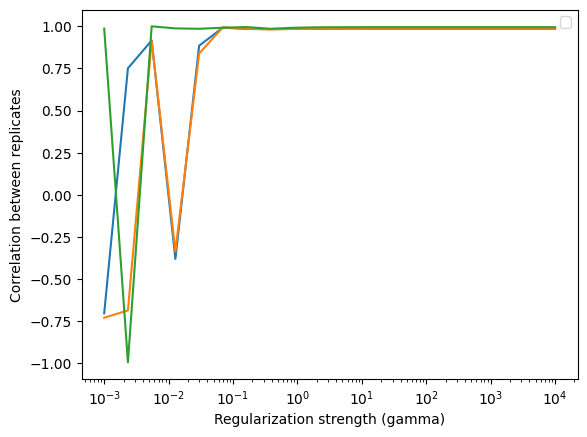

Layer 1 embeddings: 13596
corrs_list: [[np.float64(-0.4607495598273814), np.float64(-0.00204999031045432), np.float64(-0.6730324948551912)], [np.float64(-0.4798487588608676), np.float64(-0.4103623612567173), np.float64(0.9807096284962111)], [np.float64(-0.47130678000106474), np.float64(0.180990933144056), np.float64(0.7590301669681979)], [np.float64(0.900190938048975), np.float64(-0.601797634488513), np.float64(-0.8390840232728682)], [np.float64(0.9375726146261008), np.float64(0.9287934578016039), np.float64(0.9603892334951871)], [np.float64(0.8238253335930892), np.float64(0.850752848835242), np.float64(0.9712346018097582)], [np.float64(0.21515382597898217), np.float64(0.4233560433916749), np.float64(0.9591141013544013)], [np.float64(0.9913097270957645), np.float64(0.9883040192412006), np.float64(0.9975699846315186)], [np.float64(0.8324743322852285), np.float64(0.996121016300731), np.float64(0.8696638305677149)], [np.float64(0.9928747408365604), np.float64(0.9931644265083855), np.float

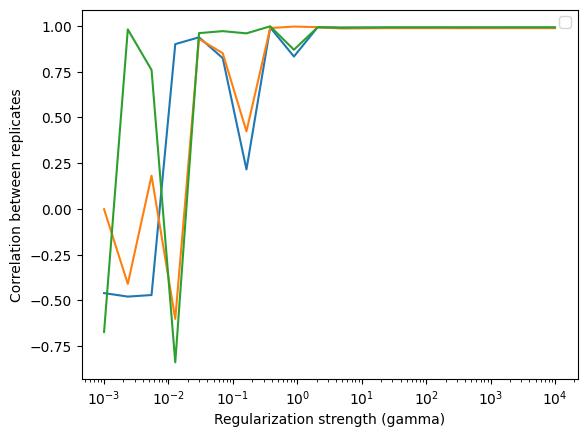

Layer 2 embeddings: 13596
corrs_list: [[np.float64(0.22548820717974943), np.float64(0.17347496130632764), np.float64(0.3393716333882062)], [np.float64(0.5190427590376266), np.float64(-0.009242094585517547), np.float64(0.4670651738900342)], [np.float64(0.5352755176689596), np.float64(0.6388193421837689), np.float64(0.9641896047992546)], [np.float64(-0.5398694168807578), np.float64(0.36564038885186223), np.float64(-0.5940961178947526)], [np.float64(-0.3639507315151471), np.float64(-0.07750660307911988), np.float64(0.1276384116986521)], [np.float64(-0.10865550213908552), np.float64(-0.09994782566510915), np.float64(0.8779211570552434)], [np.float64(0.7530310744042185), np.float64(0.7294556955977969), np.float64(0.9695564343803387)], [np.float64(0.9334463264025575), np.float64(0.9115946035094701), np.float64(0.985066737684641)], [np.float64(0.9862621549431412), np.float64(0.9715814873949722), np.float64(0.9963420983231099)], [np.float64(0.9944093927760662), np.float64(0.9904266467570986), 

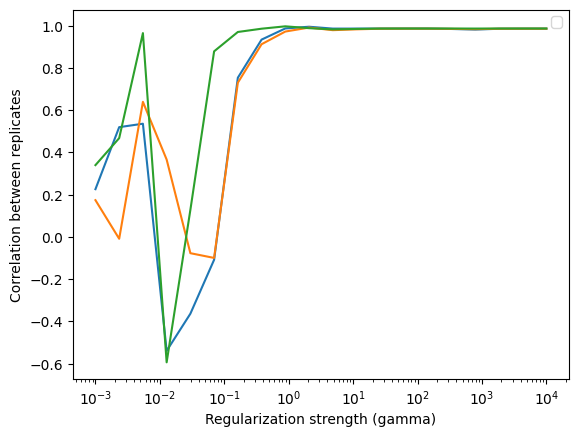

Layer 3 embeddings: 13596
corrs_list: [[np.float64(0.634677249915036), np.float64(0.7141908240404972), np.float64(0.986302964559785)], [np.float64(0.6181000851614461), np.float64(0.7077666606027089), np.float64(0.9820901783748961)], [np.float64(0.4138779984497951), np.float64(0.7133435782384325), np.float64(0.8798871409032125)], [np.float64(-0.7030218915635613), np.float64(0.7822952074971761), np.float64(-0.10963340248142972)], [np.float64(-0.09542089415268737), np.float64(-0.5636598247188503), np.float64(0.5718438503273787)], [np.float64(0.6927427995329434), np.float64(0.6631930905912038), np.float64(0.7836795989448552)], [np.float64(0.8858368339359106), np.float64(0.9551466149515209), np.float64(0.931350221709227)], [np.float64(0.9880024984075086), np.float64(0.9788744465592181), np.float64(0.9927900928855911)], [np.float64(0.992694277602207), np.float64(-0.9815807301183921), np.float64(-0.9927741731274824)], [np.float64(0.9879578351105471), np.float64(0.9863309669273876), np.float64

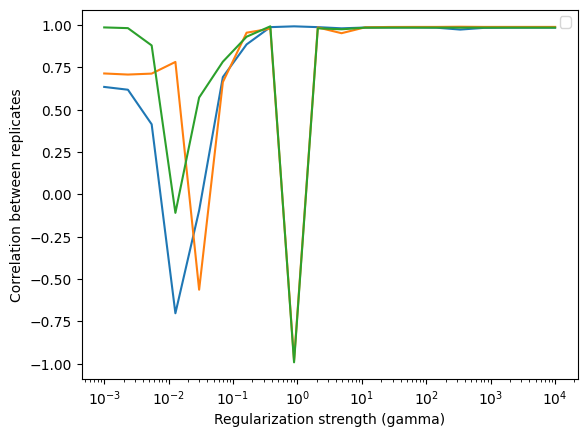

Layer 4 embeddings: 13596
corrs_list: [[np.float64(0.8418029535245953), np.float64(0.7534017079171776), np.float64(0.9473060679396257)], [np.float64(0.8269147019125318), np.float64(0.6818270210366651), np.float64(0.4955420193308927)], [np.float64(0.030489133874683966), np.float64(0.5886334023436056), np.float64(-0.7273066302368167)], [np.float64(0.6798124638933077), np.float64(0.5090918653954934), np.float64(-0.24390487441383119)], [np.float64(0.5433001788191159), np.float64(0.8573660061477038), np.float64(0.14572954831860196)], [np.float64(0.5268323519308304), np.float64(0.3759397851417748), np.float64(0.9003899090562678)], [np.float64(0.8955456259145209), np.float64(0.8944595885461937), np.float64(0.9447384230171726)], [np.float64(0.4578230919249796), np.float64(0.5952363399356084), np.float64(0.9367074748456643)], [np.float64(0.9710326578686173), np.float64(0.9889509862492016), np.float64(0.9798510100042719)], [np.float64(0.9765889988416319), np.float64(0.982370107381363), np.float6

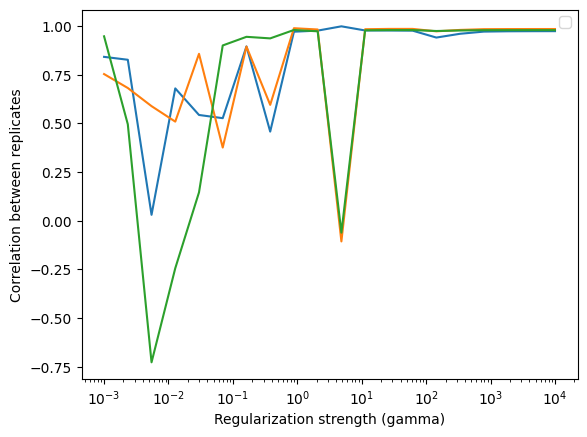

Layer 5 embeddings: 13596
corrs_list: [[np.float64(-0.6221054882437873), np.float64(0.3078948385406219), np.float64(0.5130126368508604)], [np.float64(0.8881205199572665), np.float64(0.4830922719196076), np.float64(0.1920887103375466)], [np.float64(0.8116188140372225), np.float64(0.9107285481996436), np.float64(0.9273215013607241)], [np.float64(-0.0927135398183847), np.float64(-0.940815689556111), np.float64(0.03527428999787956)], [np.float64(-0.5185386853433585), np.float64(0.3298500859914638), np.float64(-0.36834715025205866)], [np.float64(0.41629203133763326), np.float64(0.5814143343427616), np.float64(-0.45152058496805797)], [np.float64(0.8415687059935412), np.float64(0.9393754792773097), np.float64(0.9699150923322474)], [np.float64(0.36630860393087866), np.float64(0.618778860113607), np.float64(0.9198950702372213)], [np.float64(0.9783224296638595), np.float64(0.9875941487845408), np.float64(0.9943939379588218)], [np.float64(0.9791919602914642), np.float64(0.9839000572167522), np.fl

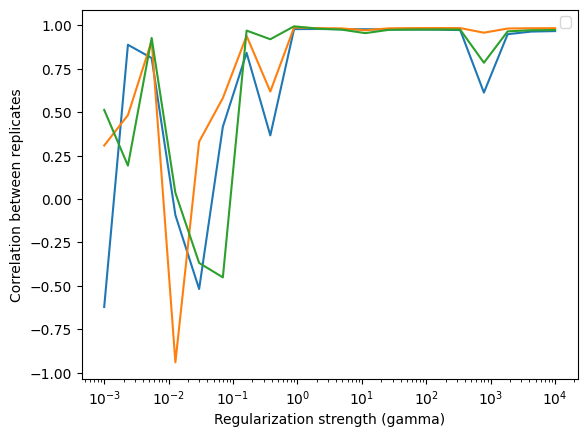

Layer 6 embeddings: 13596
corrs_list: [[np.float64(-0.7438499985341807), np.float64(-0.2048832800912314), np.float64(-0.17796026684916977)], [np.float64(-0.6350574756841276), np.float64(-0.1553065463405618), np.float64(0.8067860218136514)], [np.float64(0.11300248946389746), np.float64(-0.2163563827608409), np.float64(0.09240058115175073)], [np.float64(0.9633703145204957), np.float64(0.9745481321006411), np.float64(0.9411316848893161)], [np.float64(0.9206589074594589), np.float64(0.9114880067176467), np.float64(0.9879819975071977)], [np.float64(0.46312731534858304), np.float64(0.48884392474931837), np.float64(0.964277372199689)], [np.float64(0.8752494545229368), np.float64(0.9991550118169101), np.float64(0.870332301450081)], [np.float64(0.9720969347868831), np.float64(0.7376671637903395), np.float64(0.6933446780931681)], [np.float64(0.961439474749685), np.float64(-0.8309740231225101), np.float64(-0.9514971607806925)], [np.float64(0.9808831137278972), np.float64(0.9795225237928097), np.f

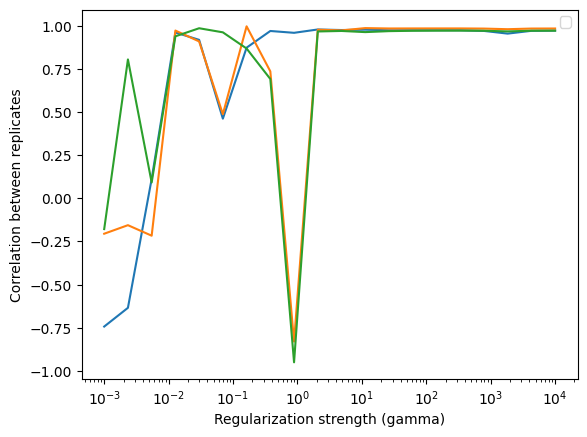

Layer 7 embeddings: 13596
corrs_list: [[np.float64(-0.5980481691395355), np.float64(-0.4813535032959843), np.float64(0.9877387482023905)], [np.float64(-0.6510196363064046), np.float64(-0.6238922280177815), np.float64(0.9734639820158683)], [np.float64(0.6244547824827764), np.float64(0.4887530490204097), np.float64(0.9653617668451587)], [np.float64(-0.2949136861278311), np.float64(-0.8173630517053432), np.float64(0.6417869852716835)], [np.float64(0.9695489798230968), np.float64(0.9664960986522666), np.float64(0.979849489516571)], [np.float64(-0.5429978916850207), np.float64(-0.6514079038542907), np.float64(0.9434946340383245)], [np.float64(0.5414236829355902), np.float64(0.6647576166808655), np.float64(0.8972744252352726)], [np.float64(-0.33687296131990385), np.float64(0.19072306482353696), np.float64(-0.8693962667881447)], [np.float64(0.8431986305273336), np.float64(0.9773142026349365), np.float64(0.9181768667755482)], [np.float64(0.9958214060844396), np.float64(0.9969634707875363), np.

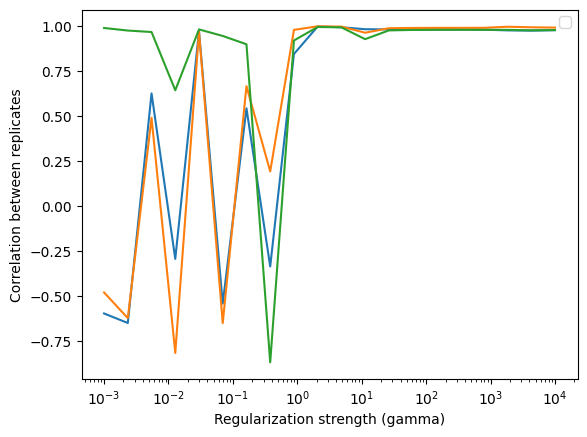

Layer 8 embeddings: 13596
corrs_list: [[np.float64(-0.1524856226333301), np.float64(-0.28496866708593754), np.float64(0.9711806218180731)], [np.float64(-0.421130239711957), np.float64(-0.4717717217085418), np.float64(0.9495877460603919)], [np.float64(0.7245473466803677), np.float64(0.4687634192227832), np.float64(0.0741126726556092)], [np.float64(0.9417448535771757), np.float64(0.33185300026966214), np.float64(0.44728260816107596)], [np.float64(-0.7740803567250594), np.float64(0.960649027385927), np.float64(-0.5879601135147094)], [np.float64(0.3558289193985871), np.float64(-0.9424983470690766), np.float64(-0.024889815824205234)], [np.float64(-0.31682737753188267), np.float64(0.47883778402144156), np.float64(-0.9593353964910182)], [np.float64(0.6908009028889319), np.float64(0.6111129936915066), np.float64(0.9709377780693992)], [np.float64(0.9694784655714925), np.float64(0.9187660565690513), np.float64(0.9754199113797094)], [np.float64(0.9816303896887812), np.float64(0.9922992968330535),

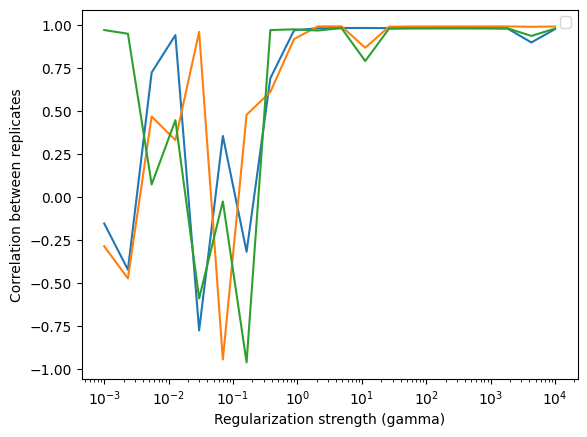

Layer 9 embeddings: 13596
corrs_list: [[np.float64(0.9356366436776894), np.float64(0.833276350762195), np.float64(0.9276910092639502)], [np.float64(0.8736780423736343), np.float64(0.8309055058449706), np.float64(0.9609503356329792)], [np.float64(0.5938510040375351), np.float64(0.7140496439543736), np.float64(0.9741216590253041)], [np.float64(0.29867949990860565), np.float64(-0.3775410684141851), np.float64(0.726891492423519)], [np.float64(0.618833956360689), np.float64(0.6126215108801705), np.float64(0.9912883707218616)], [np.float64(0.9352294977591751), np.float64(-0.6538407818675733), np.float64(-0.8665712395037909)], [np.float64(0.14776031439345855), np.float64(-0.3661447769971417), np.float64(0.2294810025479159)], [np.float64(0.9753277430829285), np.float64(0.986788101416294), np.float64(0.9883045068318841)], [np.float64(0.9537844478117377), np.float64(0.9812920684708228), np.float64(0.9780602362557644)], [np.float64(0.9909717778577503), np.float64(0.9941345201306575), np.float64(0

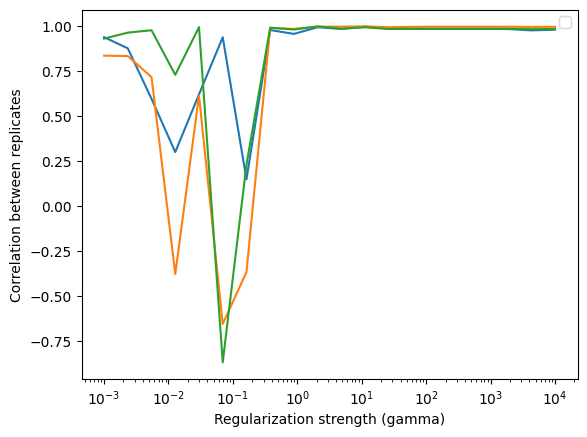

Layer 10 embeddings: 13596
corrs_list: [[np.float64(0.3125292422208284), np.float64(0.3436760613049875), np.float64(0.3792530343627531)], [np.float64(0.2860524720739175), np.float64(0.06143696149739161), np.float64(0.870387226183936)], [np.float64(-0.1350814565524465), np.float64(-0.3544290122490742), np.float64(0.7773412710230604)], [np.float64(0.10274392718545769), np.float64(-0.6883954367611074), np.float64(-0.4242734949145916)], [np.float64(0.7857991157782698), np.float64(0.3643583604078091), np.float64(0.5748954063336684)], [np.float64(0.2943460022504996), np.float64(-0.24140339675450107), np.float64(-0.2081800793514949)], [np.float64(-0.46838981711670963), np.float64(0.4383928614732695), np.float64(0.43329572385971216)], [np.float64(0.8118091632315156), np.float64(0.924456884382729), np.float64(0.8489543335620067)], [np.float64(-0.42741338621684616), np.float64(0.6862829736069425), np.float64(-0.9368138464283517)], [np.float64(0.9758780265540247), np.float64(0.9926539866592148), 

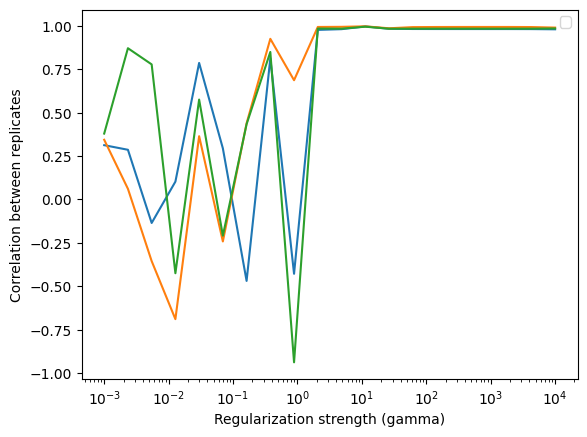

Layer 11 embeddings: 13596
corrs_list: [[np.float64(-0.6236548148283212), np.float64(0.14673100117379573), np.float64(0.057792771237567035)], [np.float64(0.7030385108355465), np.float64(-0.46251153779539134), np.float64(-0.7554703757772431)], [np.float64(0.07418902636860542), np.float64(-0.10767077209281062), np.float64(0.9536610729541753)], [np.float64(0.8583837942380621), np.float64(0.9305472069014026), np.float64(0.9598872833322799)], [np.float64(-0.5827961683436275), np.float64(-0.14108732693882092), np.float64(0.6593617174226247)], [np.float64(0.957590119904369), np.float64(0.9614343567078524), np.float64(0.9682680065104847)], [np.float64(0.9091913819445697), np.float64(0.9268738104863872), np.float64(0.9636631451356457)], [np.float64(0.03444822642508285), np.float64(-0.07199648937465203), np.float64(0.5426466514261254)], [np.float64(-0.5039564649924345), np.float64(-0.7281996843083969), np.float64(0.9313507313662286)], [np.float64(0.959785147037562), np.float64(0.9924892517849316

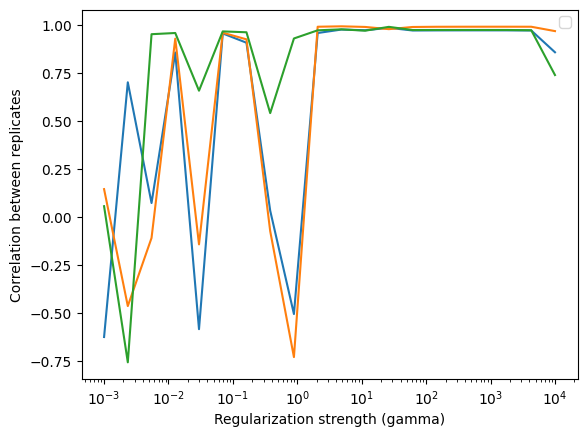

Layer 12 embeddings: 13596
corrs_list: [[np.float64(-0.23611141184237416), np.float64(-0.6991399363892783), np.float64(0.042311955044925964)], [np.float64(0.8423513733171708), np.float64(0.8801174250071933), np.float64(0.9355667040634337)], [np.float64(0.4363139609971683), np.float64(-0.2199458387157422), np.float64(0.737729372612717)], [np.float64(0.136929932565522), np.float64(-0.01718067821750835), np.float64(0.4565202796083757)], [np.float64(0.7709369572998606), np.float64(0.6884867921509912), np.float64(0.9798837625094378)], [np.float64(0.7889791060571635), np.float64(0.870864930480622), np.float64(0.9254451821327271)], [np.float64(0.9105566891910803), np.float64(0.9421881363111902), np.float64(0.9753989765443443)], [np.float64(0.9770562179423575), np.float64(0.9939724715057935), np.float64(0.9780171046427213)], [np.float64(0.9770482309333937), np.float64(0.9918623238155624), np.float64(0.9802516826487337)], [np.float64(0.9772313694720327), np.float64(0.9882899467299766), np.float

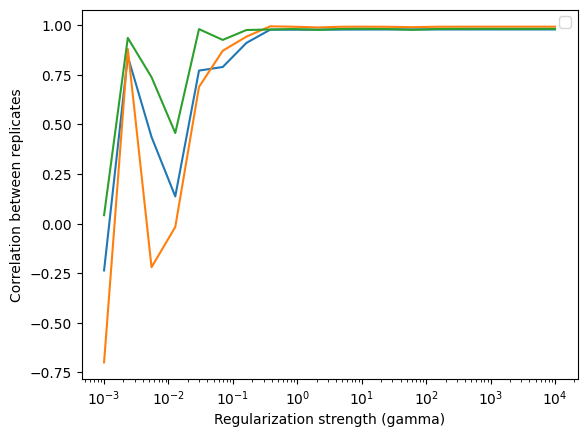

In [24]:
from popDMS import mini_infer_independent_esm

dataset = "TpoR"

dataset_results = {}
embeddings = test_embed_df["Embedding"].tolist()
LAYERS = 13
for layer in range(LAYERS):
    layer_embeds = [embeddings[i][layer] for i in range(len(embeddings))]
    print(f"Layer {layer} embeddings: {len(layer_embeds)}") 
    layer_df = test_embed_df.copy()
    layer_df["Embedding"] = layer_embeds
    layer_inference_data = mini_infer_independent_esm(layer_df, n_replicates=3, gamma=None, corr_cutoff_pct=0.5,
                                                   max_reads=1e3, output_dir=None, name='esm_inference', plot_gamma=True,
                                                   verbose=True, calc_error_bars=False,
                                                   variance_cutoff=0.0, infer_ignored_dims=True)
    dataset_results[layer] = layer_inference_data

In [28]:
# Processing into simulation format
all_results_fullcov = {}

LAYERS = list(range(13))

processed_dataset_results = {}
for layer in LAYERS:
    #print(f"Processing layer {layer} into simulation format...")
    
    layer_inference_data = dataset_results[layer]

    #layer_results = [data[2], data[3], data[7], data[8], data[1], data[5]]

    layer_results = [layer_inference_data[2], layer_inference_data[3], layer_inference_data[7], layer_inference_data[8], layer_inference_data[1], layer_inference_data[5]]
    processed_dataset_results[layer] = layer_results
all_results_fullcov[dataset] = [None, None, processed_dataset_results, None, None]
print("Finished processing datasets into simulation format.")

Finished processing datasets into simulation format.


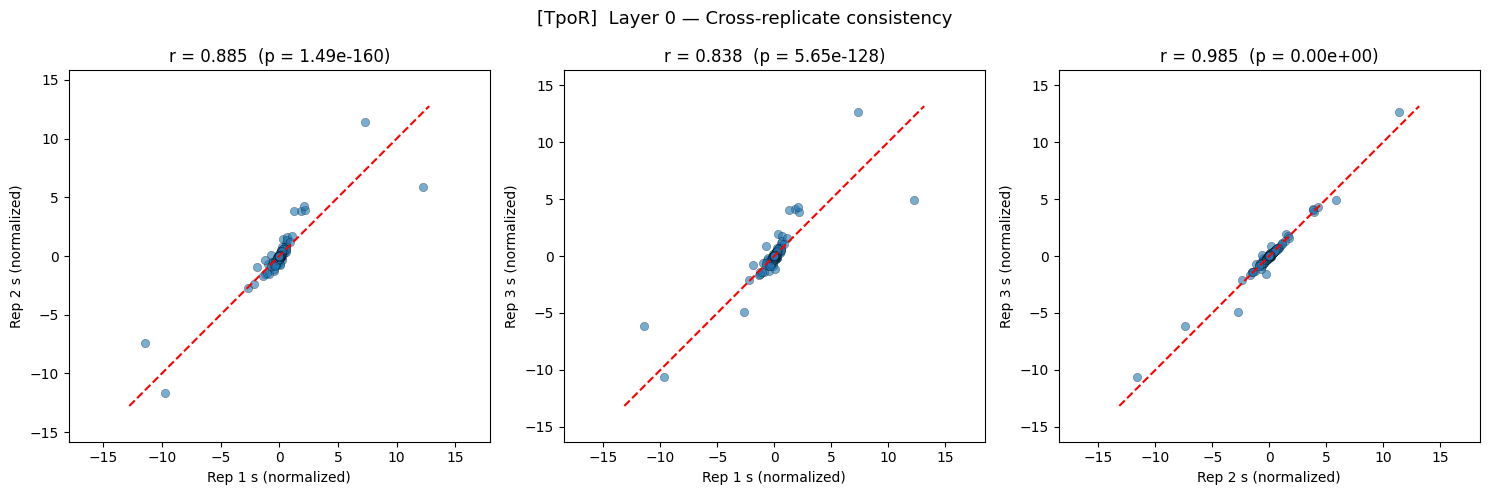

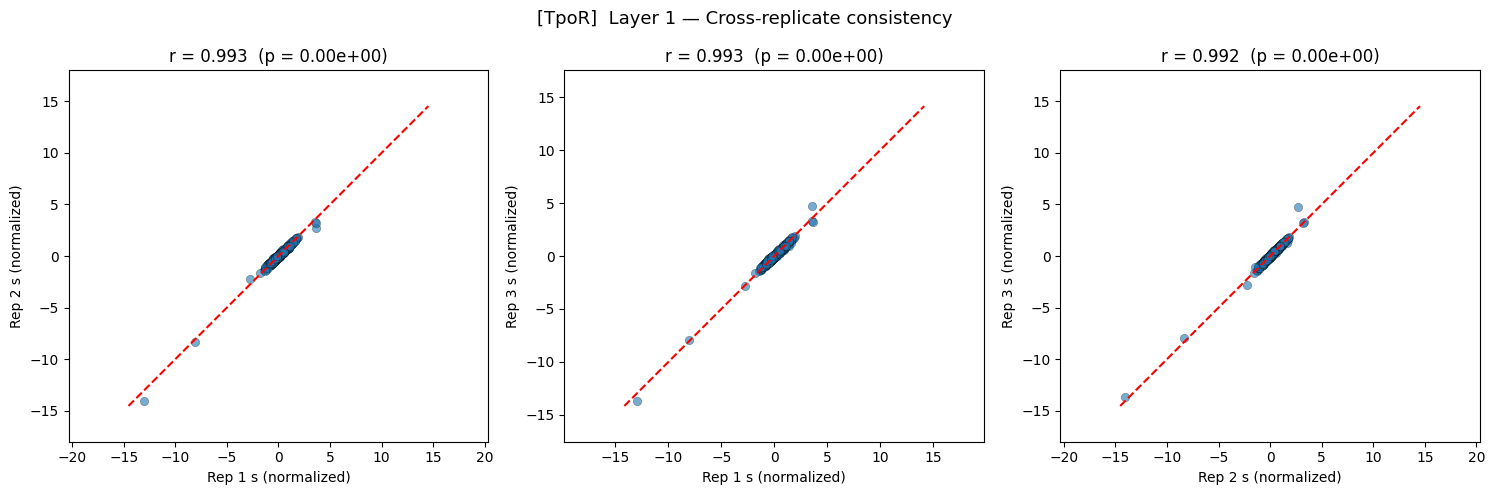

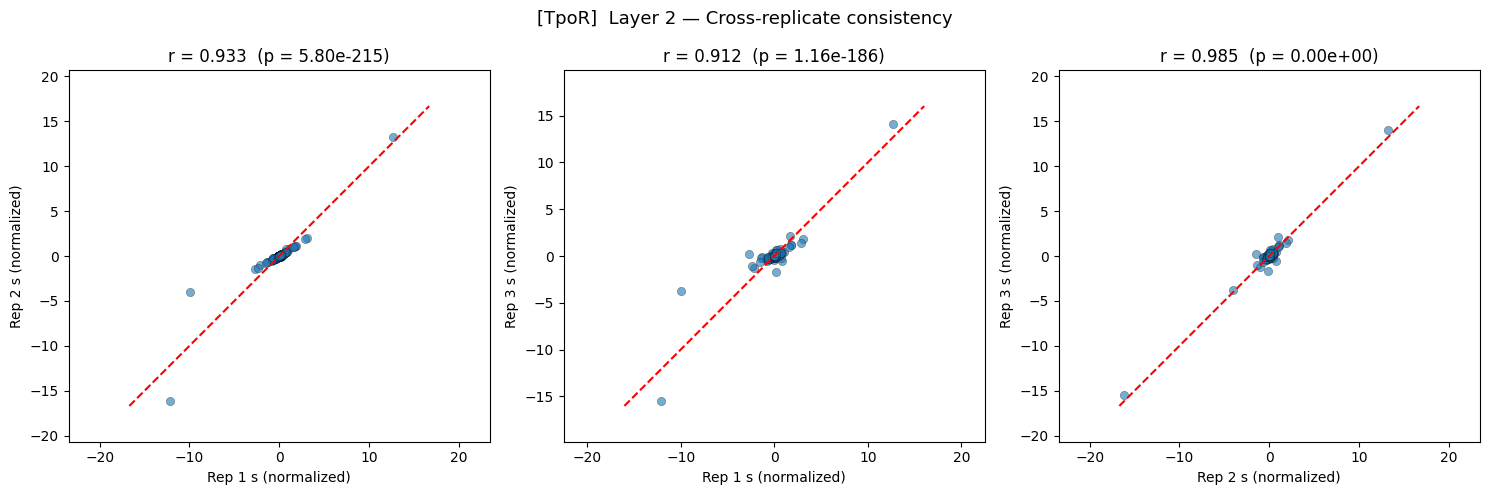

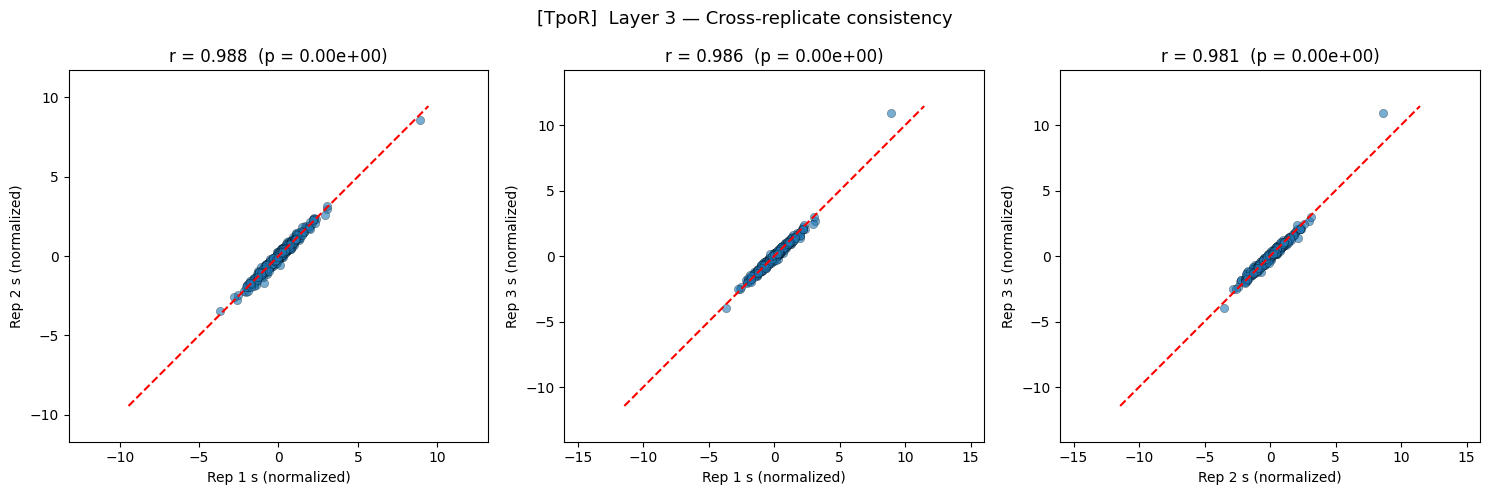

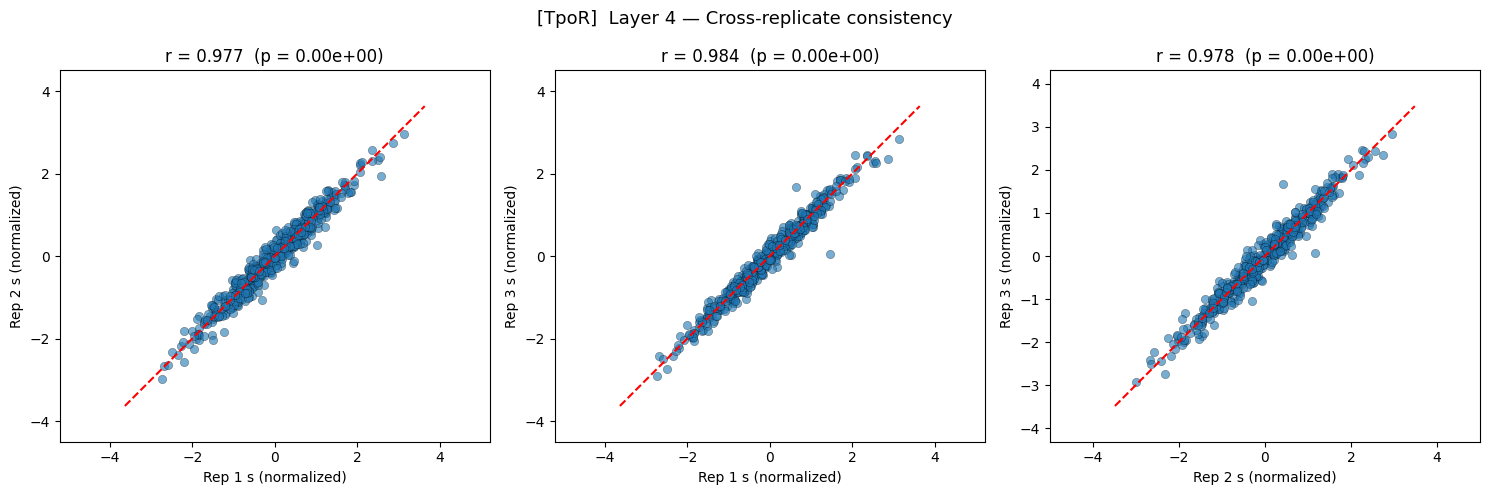

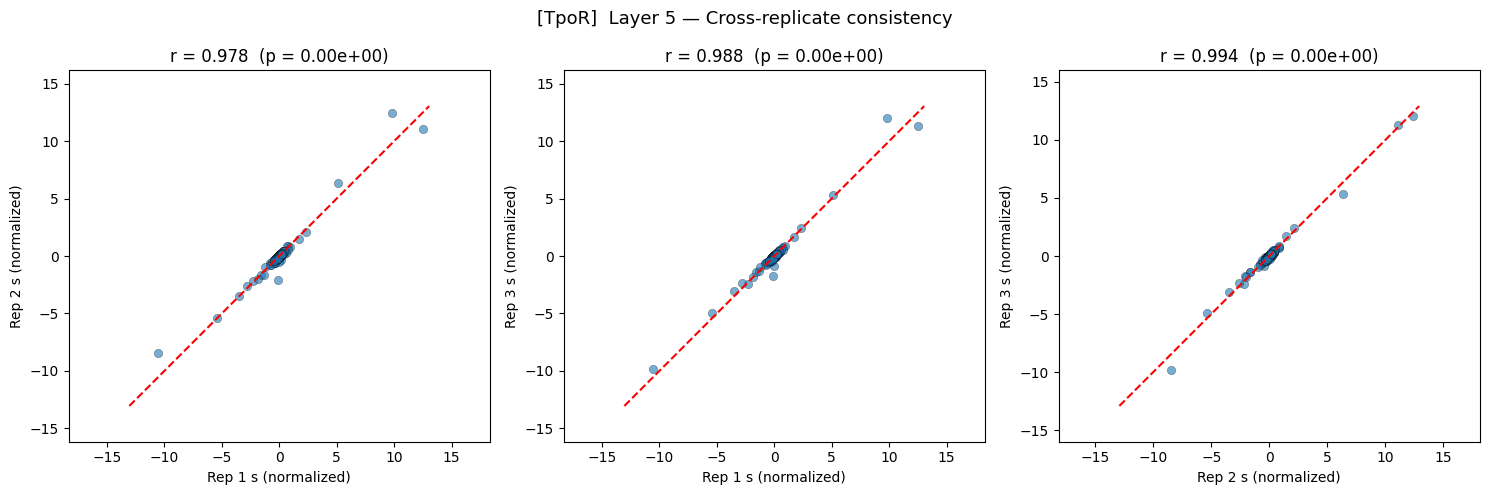

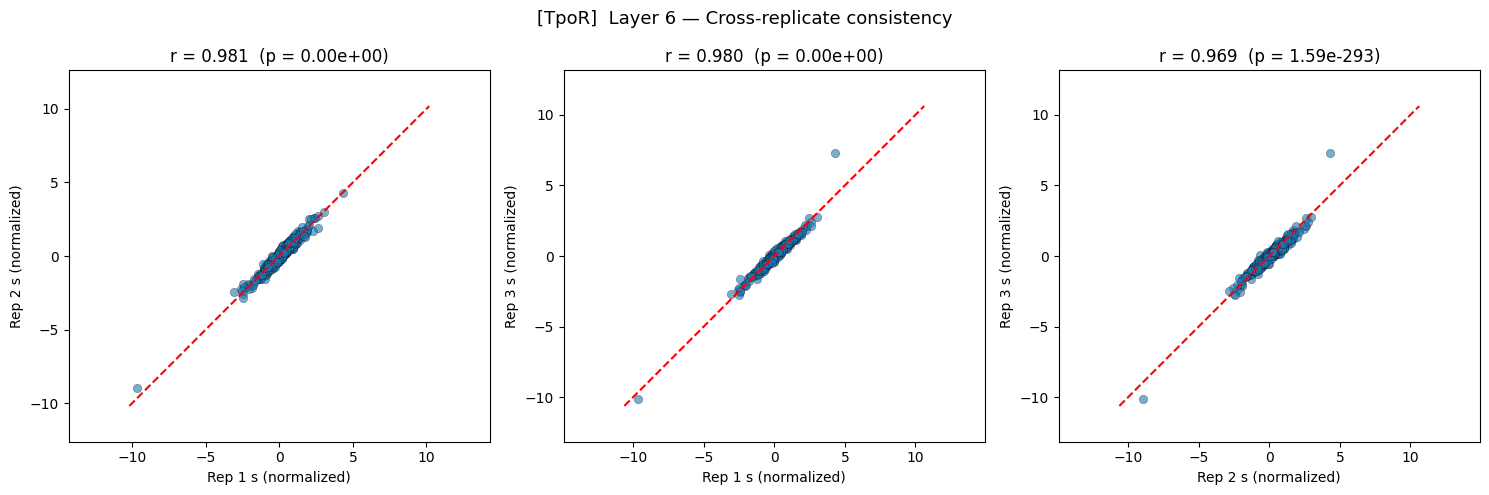

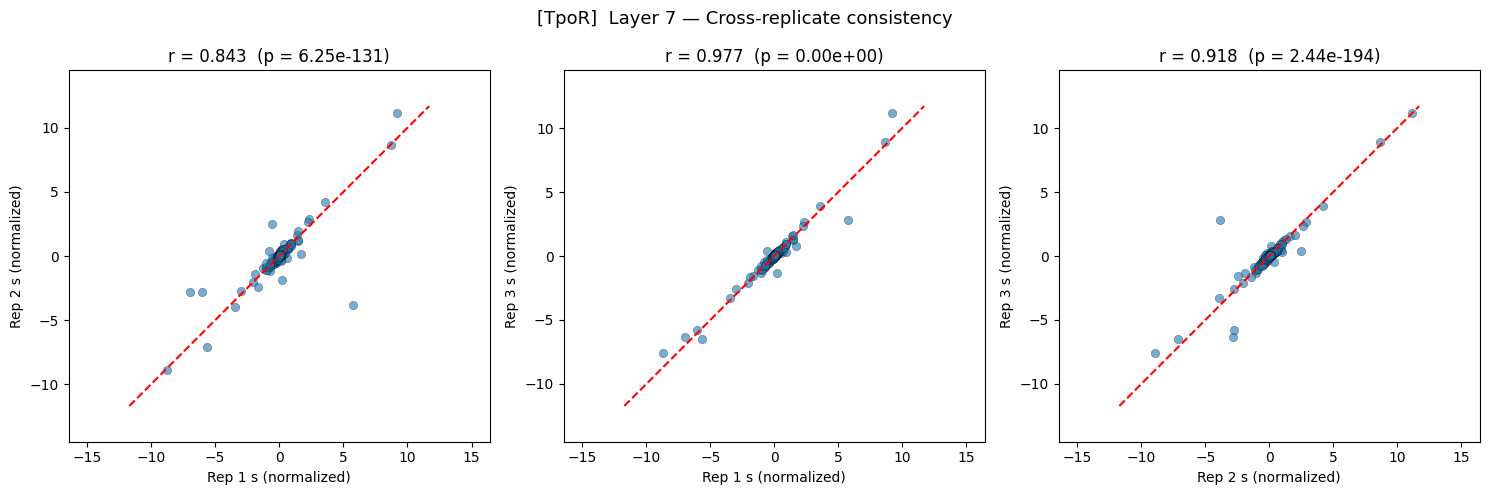

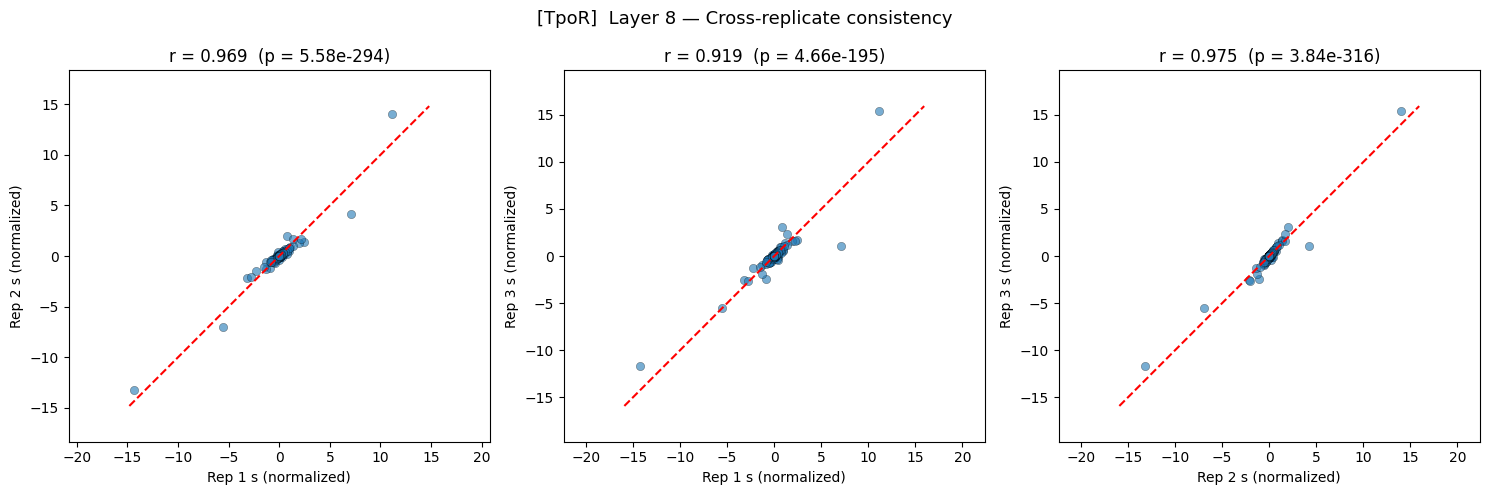

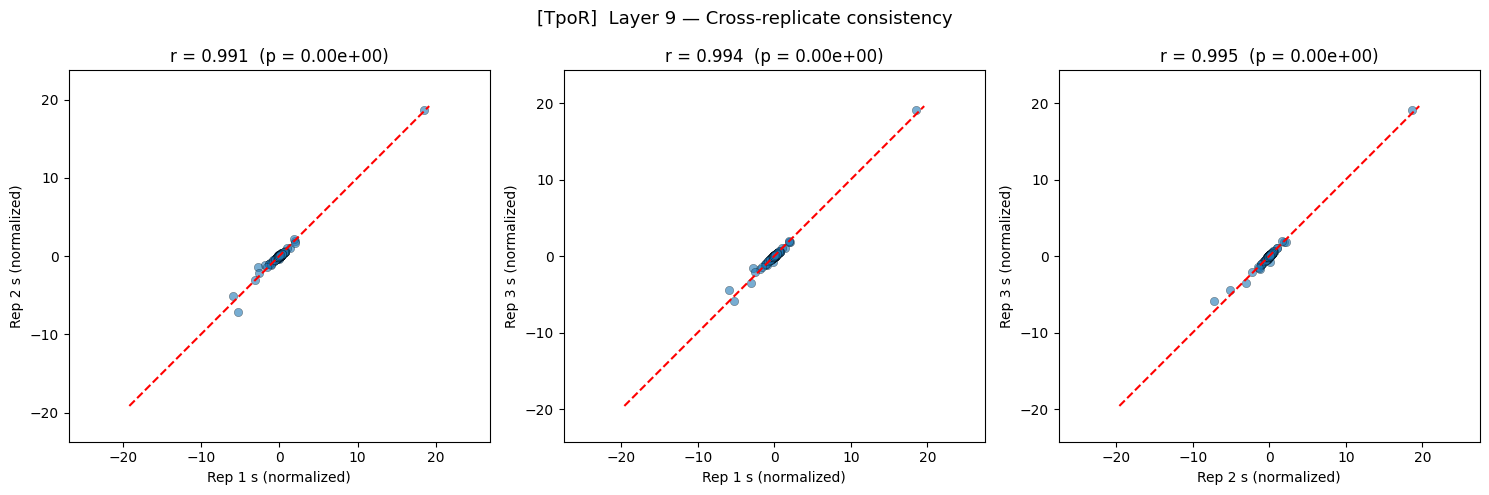

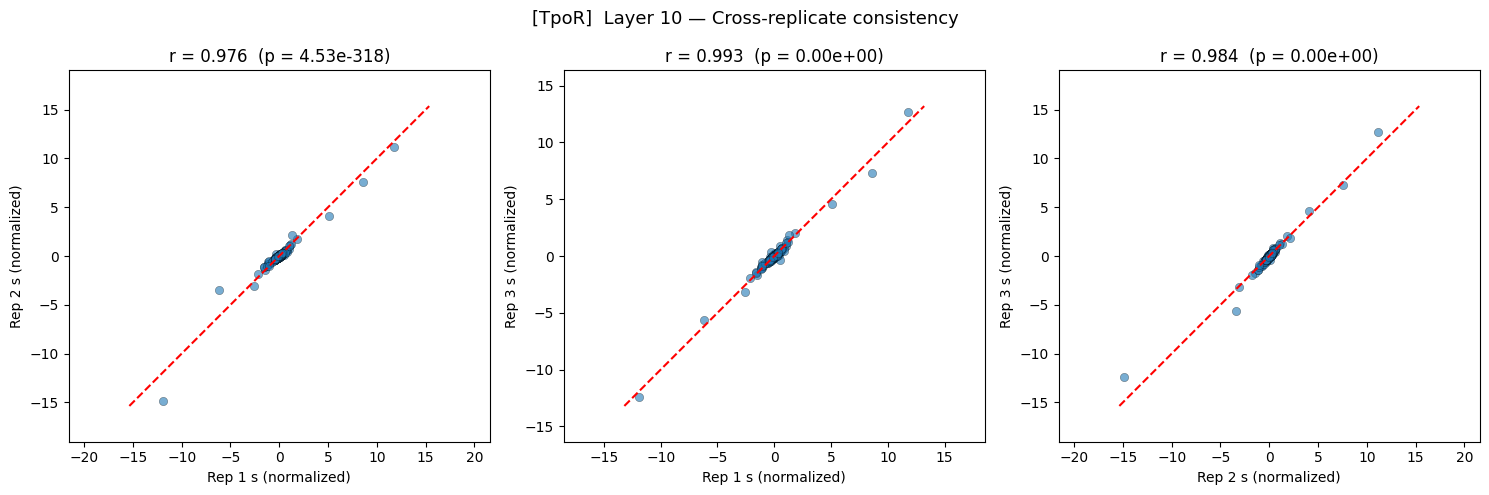

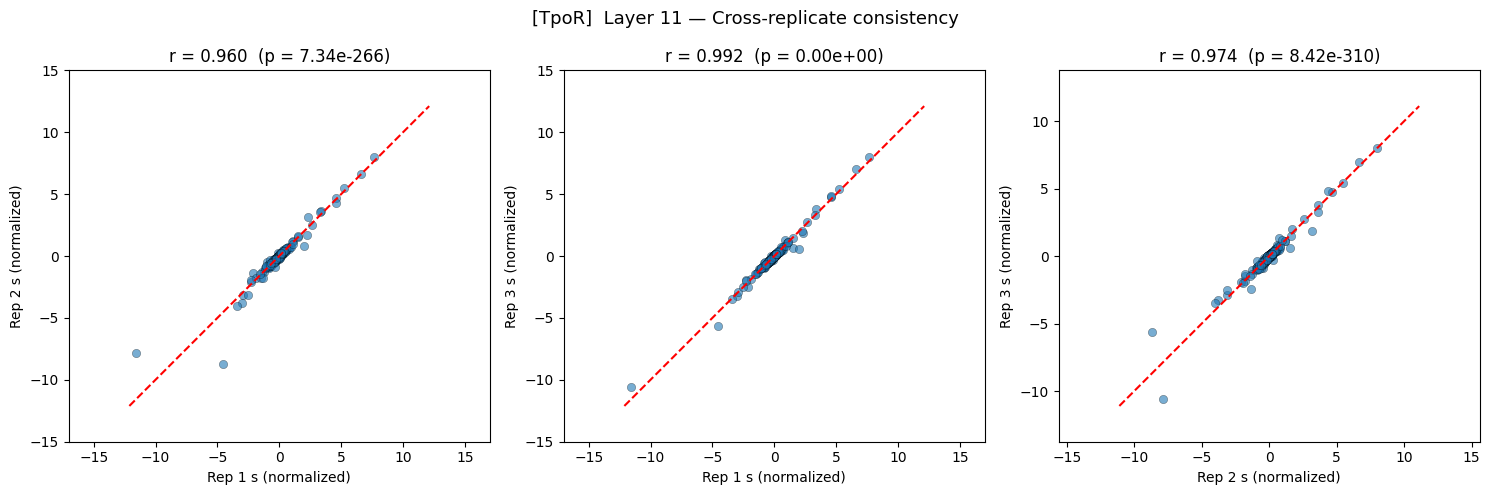

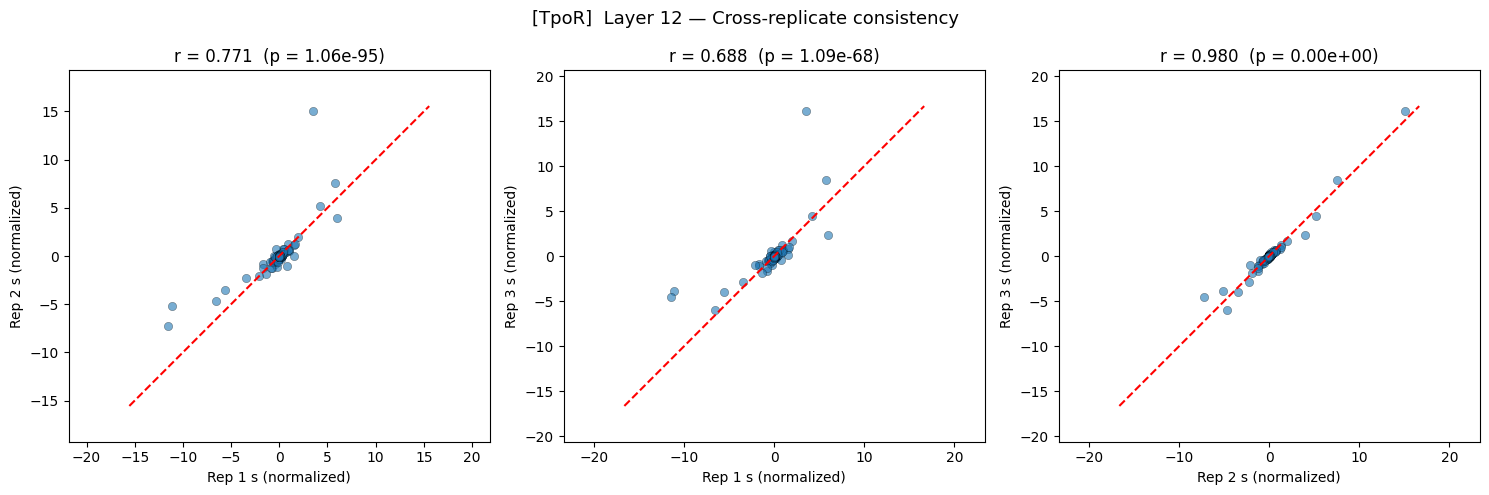

In [29]:
from analysis_helpers import plot_cross_replicate_consistency
plot_cross_replicate_consistency(all_results_fullcov, LAYERS)

Dataset: TpoR


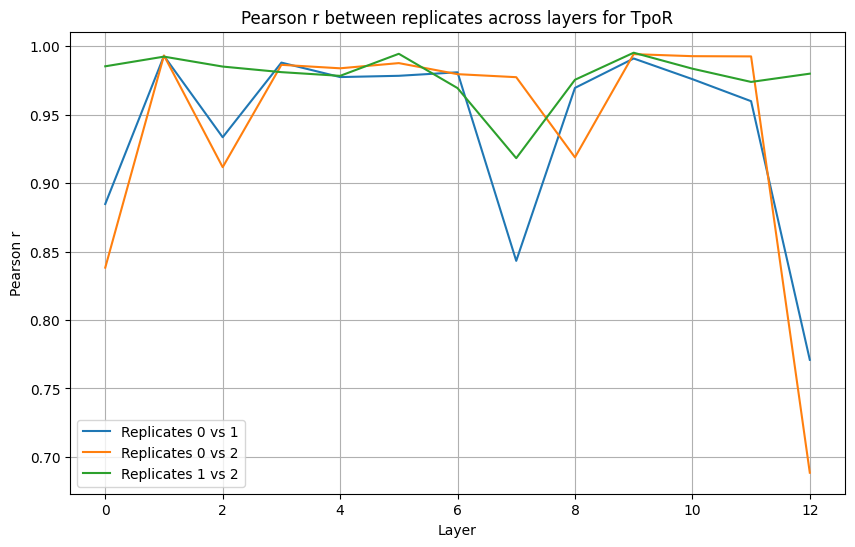

In [32]:
# Plot the pearson r correlation between replicates by layer
dataset_pearson_results = {}

from scipy.stats import pearsonr
import matplotlib.pyplot as plt

active_datasets = [dataset]  # Only process the TpoR dataset for now

for dataset in active_datasets:
    print(f"Dataset: {dataset}")
    dataset_results = all_results_fullcov[dataset][2]  # Get the detailed results for this dataset
    dataset_pearson_results[dataset] = {}
    for layer in LAYERS:
        if layer not in dataset_results:
            print(f"  Layer {layer} not found in results.")
            continue
        layer_results = dataset_results[layer]
        replicate_pairs = [(0, 1), (0, 2), (1, 2)]
        r_values = []
        for replicate_pair in replicate_pairs:
            replicate_1 = layer_results[0][replicate_pair[0]]
            replicate_2 = layer_results[0][replicate_pair[1]]
            r, _ = pearsonr(replicate_1, replicate_2)
            r_values.append(r)
        
        dataset_pearson_results[dataset][layer] = r_values

# Plot the pearson r across layers for each dataset and replicate pair
for dataset in dataset_pearson_results:
    plt.figure(figsize=(10, 6))
    for i, replicate_pair in enumerate([(0, 1), (0, 2), (1, 2)]):
        r_values = [dataset_pearson_results[dataset][layer][i] for layer in LAYERS if layer in dataset_pearson_results[dataset]]
        plt.plot(LAYERS[:len(r_values)], r_values, label=f"Replicates {replicate_pair[0]} vs {replicate_pair[1]}")
    
    plt.title(f"Pearson r between replicates across layers for {dataset}")
    plt.xlabel("Layer")
    plt.ylabel("Pearson r")
    plt.legend()
    plt.grid()
    plt.show()

